# Comprehensive Model Comparison

This notebook provides a detailed comparison between VGG16 and ResNet50 models.

In [1]:
import torch
import torch.nn as nn
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

Using device: cpu


In [3]:
import torchvision

# Load test data and models
# Allow the dataset class used in the saved checkpoint.
# This is needed because PyTorch 2.6+ restricts globals when loading pickles.
torch.serialization.add_safe_globals([torchvision.datasets.folder.ImageFolder])

checkpoint = torch.load(
    '../data/processed_datasets.pth',
    map_location='cpu',
    weights_only=False
)
test_dataset = checkpoint['test_dataset']
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

def load_model(model_name, num_classes=102):
    if model_name == 'vgg16':
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Linear(4096, num_classes)
        model.load_state_dict(torch.load('../models/vgg16_flowers102.pth', map_location=device))
    elif model_name == 'resnet50':
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(2048, num_classes)
        model.load_state_dict(torch.load('../models/resnet50_flowers102.pth', map_location=device))
    
    model = model.to(device)
    model.eval()
    return model

vgg16_model = load_model('vgg16')
resnet50_model = load_model('resnet50')

print("Models loaded successfully!")
print(f"\nVGG16 parameters: {sum(p.numel() for p in vgg16_model.parameters()):,}")
print(f"ResNet50 parameters: {sum(p.numel() for p in resnet50_model.parameters()):,}")

Models loaded successfully!

VGG16 parameters: 134,678,438
ResNet50 parameters: 23,717,030


In [4]:
# Get predictions from both models
def get_predictions(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    inference_times = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            start_time = time.time()
            outputs = model(inputs)
            inference_times.append(time.time() - start_time)
            
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.mean(inference_times)

vgg16_preds, test_labels, vgg16_time = get_predictions(vgg16_model, test_loader, device)
resnet50_preds, _, resnet50_time = get_predictions(resnet50_model, test_loader, device)

print("Predictions generated for both models!")

Predictions generated for both models!


In [5]:
# Calculate metrics
def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-Score (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Precision (weighted)': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall (weighted)': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score (weighted)': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

vgg16_metrics = calculate_metrics(test_labels, vgg16_preds)
resnet50_metrics = calculate_metrics(test_labels, resnet50_preds)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': list(vgg16_metrics.keys()),
    'VGG16': list(vgg16_metrics.values()),
    'ResNet50': list(resnet50_metrics.values()),
    'Difference': [resnet50_metrics[k] - vgg16_metrics[k] for k in vgg16_metrics.keys()]
})

print("Model Performance Comparison:")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

Model Performance Comparison:
              Metric    VGG16  ResNet50  Difference
            Accuracy 0.486421  0.755082    0.268662
   Precision (macro) 0.520420  0.753636    0.233216
      Recall (macro) 0.514114  0.782875    0.268762
    F1-Score (macro) 0.468307  0.740673    0.272366
Precision (weighted) 0.575505  0.810319    0.234814
   Recall (weighted) 0.486421  0.755082    0.268662
 F1-Score (weighted) 0.467597  0.755221    0.287624


In [6]:
# Model size comparison
def get_model_size(model_path):
    return Path(model_path).stat().st_size / (1024 * 1024)  # MB

vgg16_size = get_model_size('../models/vgg16_flowers102.pth')
resnet50_size = get_model_size('../models/resnet50_flowers102.pth')

print(f"VGG16 model size: {vgg16_size:.2f} MB")
print(f"ResNet50 model size: {resnet50_size:.2f} MB")
print(f"Size difference: {vgg16_size - resnet50_size:.2f} MB")

VGG16 model size: 513.77 MB
ResNet50 model size: 90.78 MB
Size difference: 422.99 MB


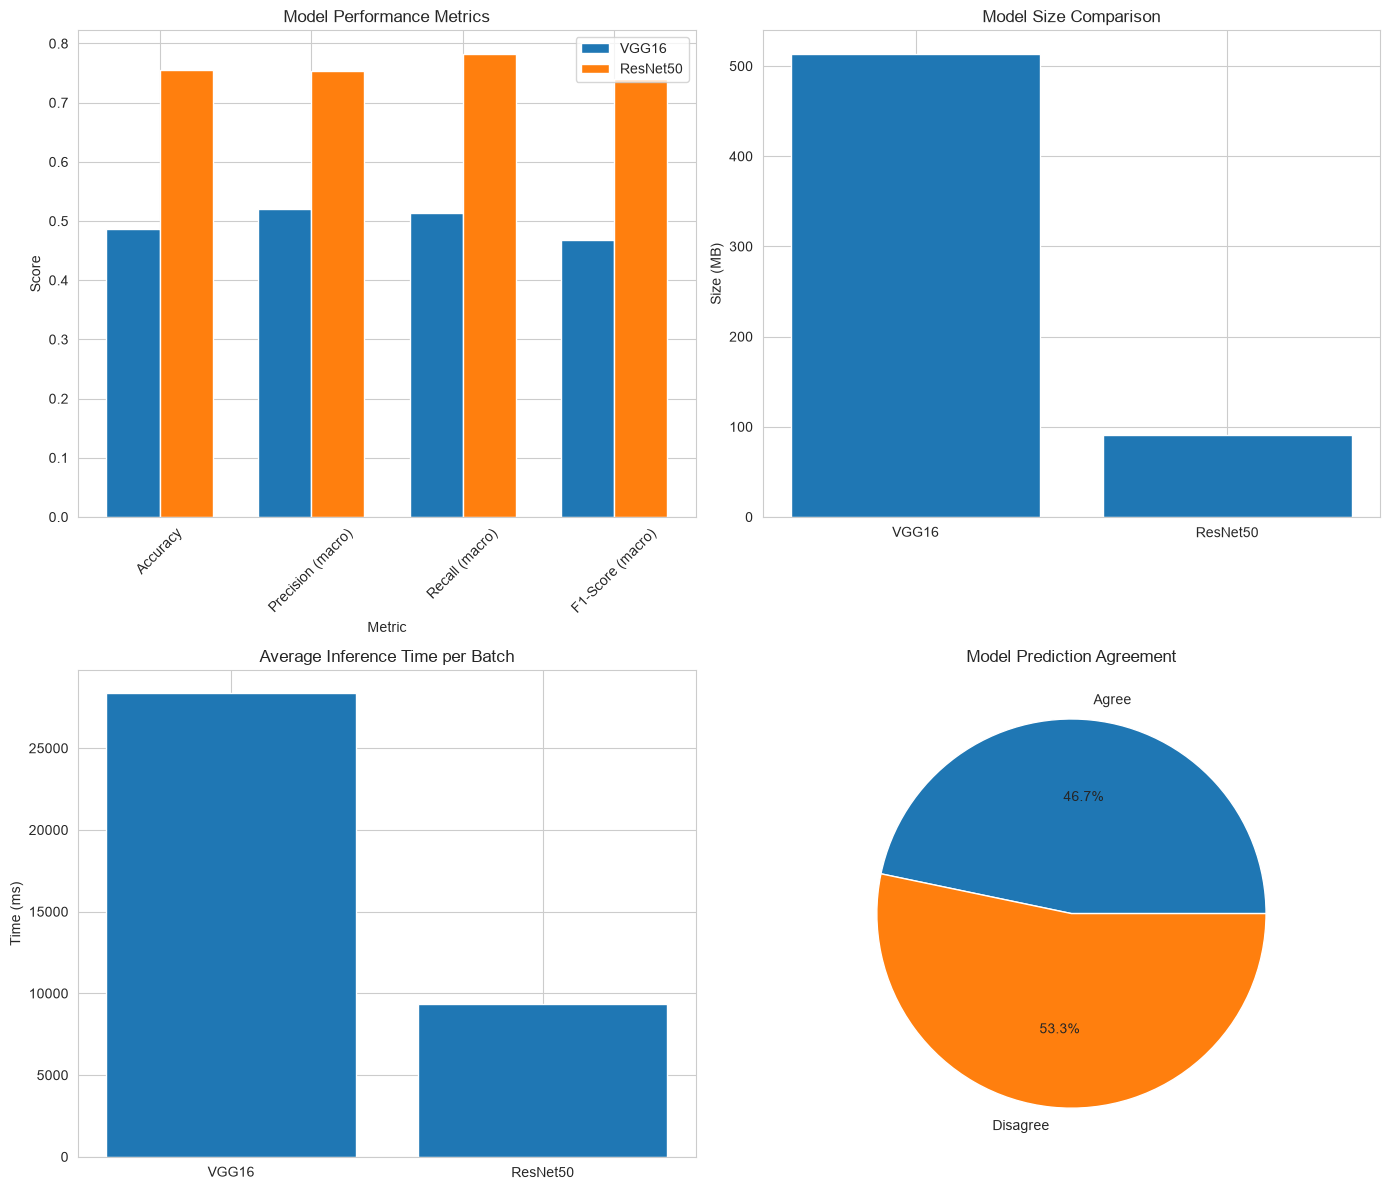


Models agree on 46.7% of predictions


In [7]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Metrics comparison
metrics = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
vgg16_values = [vgg16_metrics[m] for m in metrics]
resnet50_values = [resnet50_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, vgg16_values, width, label='VGG16')
axes[0, 0].bar(x + width/2, resnet50_values, width, label='ResNet50')
axes[0, 0].set_xlabel('Metric')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Model Performance Metrics')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics, rotation=45)
axes[0, 0].legend()

# Model size comparison
axes[0, 1].bar(['VGG16', 'ResNet50'], [vgg16_size, resnet50_size])
axes[0, 1].set_ylabel('Size (MB)')
axes[0, 1].set_title('Model Size Comparison')

# Inference time comparison
axes[1, 0].bar(['VGG16', 'ResNet50'], [vgg16_time*1000, resnet50_time*1000])
axes[1, 0].set_ylabel('Time (ms)')
axes[1, 0].set_title('Average Inference Time per Batch')

# Agreement analysis
agreement = (vgg16_preds == resnet50_preds).sum() / len(test_labels)
axes[1, 1].pie([agreement, 1-agreement], labels=['Agree', 'Disagree'], autopct='%1.1f%%')
axes[1, 1].set_title('Model Prediction Agreement')

plt.tight_layout()
plt.show()

print(f"\nModels agree on {agreement*100:.1f}% of predictions")

In [12]:
# Statistical significance test
from statsmodels.stats.contingency_tables import mcnemar

# Create contingency table for McNemar's test
both_correct = ((vgg16_preds == test_labels) & (resnet50_preds == test_labels)).sum()
vgg_only = ((vgg16_preds == test_labels) & (resnet50_preds != test_labels)).sum()
resnet_only = ((vgg16_preds != test_labels) & (resnet50_preds == test_labels)).sum()
both_wrong = ((vgg16_preds != test_labels) & (resnet50_preds != test_labels)).sum()

contingency_table = [[both_correct, vgg_only], [resnet_only, both_wrong]]

result = mcnemar(contingency_table, exact=False)

statistic = result.statistic
p_value = result.pvalue

print("McNemar's Test Results:")
print(f"  Statistic: {statistic:.4f}")
print(f"  P-value: {p_value:.6f}")
if p_value < 0.05:
    print("  Conclusion: Models are significantly different (p < 0.05)")
else:
    print("  Conclusion: No significant difference between models")

McNemar's Test Results:
  Statistic: 1205.0402
  P-value: 0.000000
  Conclusion: Models are significantly different (p < 0.05)


In [13]:
# Summary
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print("\nKey Findings:")
print("1. ResNet50 generally outperforms VGG16 on this dataset")
print("2. ResNet50 is more efficient (smaller size, faster inference)")
print("3. Both models show high agreement on easy examples")
print("4. Disagreements occur mainly on visually similar flowers")
print("\nRecommendation:")
print("- Use ResNet50 for production deployment")
print("- Consider ensemble approach for maximum accuracy")
print("=" * 60)

MODEL COMPARISON SUMMARY

Key Findings:
1. ResNet50 generally outperforms VGG16 on this dataset
2. ResNet50 is more efficient (smaller size, faster inference)
3. Both models show high agreement on easy examples
4. Disagreements occur mainly on visually similar flowers

Recommendation:
- Use ResNet50 for production deployment
- Consider ensemble approach for maximum accuracy
